# Predicting which Hogwarts house Harry Potter Characters belong to

In [32]:
import pandas as pd
import numpy as np

# for classification
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# for (re)clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Download & Inspect the data

In [33]:
# Load the CSV file for the training dataset
data = pd.read_csv('harry_potter_1000_students.csv')
df = pd.DataFrame(data)


df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw
...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,Ravenclaw
996,Pure-blood,7,3,2,7,8,6,7,7,Slytherin
997,Half-blood,5,10,5,3,3,5,7,10,Ravenclaw
998,Half-blood,5,6,10,4,4,6,2,4,Hufflepuff


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Blood Status         1000 non-null   object
 1   Bravery              1000 non-null   int64 
 2   Intelligence         1000 non-null   int64 
 3   Loyalty              1000 non-null   int64 
 4   Ambition             1000 non-null   int64 
 5   Dark Arts Knowledge  1000 non-null   int64 
 6   Quidditch Skills     1000 non-null   int64 
 7   Dueling Skills       1000 non-null   int64 
 8   Creativity           1000 non-null   int64 
 9   House                1000 non-null   object
dtypes: int64(8), object(2)
memory usage: 78.3+ KB


In [35]:
# Check if there are any missing values in the DataFrame
has_missing = data.isnull().values.any()
print("Are there any missing values?", has_missing)


# Only show columns with missing values
df.isnull().sum()[df.isnull().sum() > 0]


Are there any missing values? False


Series([], dtype: int64)

In [36]:
numeric_cols = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 
                'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity']

# Find any out-of-range values
for col in numeric_cols:
    out_of_range = df[(df[col] < 0) | (df[col] > 10)]
    if len(out_of_range) > 0:
        print(f"{col}: {len(out_of_range)} values out of range")
        print(out_of_range[[col]].head())
    else:
        print(f"{col}: All values in range ✓")

Bravery: All values in range ✓
Intelligence: All values in range ✓
Loyalty: All values in range ✓
Ambition: All values in range ✓
Dark Arts Knowledge: All values in range ✓
Quidditch Skills: All values in range ✓
Dueling Skills: All values in range ✓
Creativity: All values in range ✓


In [37]:
# Check if there are non purebloods in Slytherin
non_pureblood_slytherin = df[(df['Blood Status'].isin(['Muggle-born', 'Half-blood'])) & 
                              (df['House'] == 'Slytherin')]
print(f"Non-purebloods in Slytherin: {len(non_pureblood_slytherin)}")

slytherin = df[df['House'] == 'Slytherin']
print(f"Ratio of non purebloods in slytherin: {len(non_pureblood_slytherin)/len(slytherin)}")
print('This is strange and not correct according to the lore.')

Non-purebloods in Slytherin: 177
Ratio of non purebloods in slytherin: 0.6679245283018868
This is strange and not correct according to the lore.


In [38]:
len(df[df['House'] == 'Slytherin'])

265

## Preparing dataset for classification

### using the whole dataset

In [39]:
# Prepare features and target
# Encode Blood Status (categorical feature)
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# Select features (all numeric columns except House)
feature_cols = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                'Dueling Skills', 'Creativity']

X = df[feature_cols].values
y = df['House'].values


In [40]:
df['Blood Status Encoded'].unique()

array([0, 1, 2])

### politically-correct-only attributes (according to the lore)

In [41]:
# Prepare features and target
# Encode Blood Status (categorical feature)
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# Select features (all numeric columns except House)
feature_cols = ['Bravery', 'Intelligence', 'Loyalty', 
                'Ambition']

X = df[feature_cols].values
y = df['House'].values


### class distribution before split

In [42]:
print("\n" + "="*60)
print("HOUSE DISTRIBUTION IN ORIGINAL DATASET")
print("="*60)

unique_orig, counts_orig = np.unique(y, return_counts=True)
for house, count in zip(unique_orig, counts_orig):
    print(f"  {house:12s}: {count:3d} ({count/len(y)*100:.1f}%)")


HOUSE DISTRIBUTION IN ORIGINAL DATASET
  Gryffindor  : 226 (22.6%)
  Hufflepuff  : 251 (25.1%)
  Ravenclaw   : 258 (25.8%)
  Slytherin   : 265 (26.5%)


# Splitting data into train-test-split

In [43]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Base Classifier

In [44]:
print("\n" + "="*60)
print("HOUSE DISTRIBUTION AFTER TRAIN-TEST SPLIT")
print("="*60)

# Show class distribution
print("\nTraining set distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for house, count in zip(unique, counts):
    print(f"  {house:12s}: {count:3d} ({count/len(y_train)*100:.1f}%)")

print("\nTest set distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for house, count in zip(unique_test, counts_test):
    print(f"  {house:12s}: {count:3d} ({count/len(y_test)*100:.1f}%)")

# Create and train majority class classifier
print("\n" + "="*60)
print("MAJORITY CLASS CLASSIFIER")
print("="*60)

majority_clf = DummyClassifier(strategy='most_frequent', random_state=42)
majority_clf.fit(X_train, y_train)

# Make predictions
y_pred = majority_clf.predict(X_test)

# Find the majority class
majority_house = unique[np.argmax(counts)]
print(f"\nMajority House: {majority_house}")
print(f"Strategy: Always predict '{majority_house}'")

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")



HOUSE DISTRIBUTION AFTER TRAIN-TEST SPLIT

Training set distribution:
  Gryffindor  : 158 (22.6%)
  Hufflepuff  : 176 (25.1%)
  Ravenclaw   : 181 (25.9%)
  Slytherin   : 185 (26.4%)

Test set distribution:
  Gryffindor  :  68 (22.7%)
  Hufflepuff  :  75 (25.0%)
  Ravenclaw   :  77 (25.7%)
  Slytherin   :  80 (26.7%)

MAJORITY CLASS CLASSIFIER

Majority House: Slytherin
Strategy: Always predict 'Slytherin'

Accuracy: 0.2667 (26.67%)


# Decision Tree

In [45]:
# Train Decision Tree Classifier with Hyperparameter Tuning
print("\n" + "="*60)
print("DECISION TREE WITH HYPERPARAMETER TUNING")
print("="*60)

# Define parameters for Decision Tree
dt_param_dist = {
'max_depth': [3, 5, 7, None],
'min_samples_split': [2, 5, 10, 15, 20],
'min_samples_leaf': [1, 2, 4, 8, 10],
'criterion': ['gini', 'entropy'],
'splitter': ['best', 'random'],
'max_features': ['sqrt', 'log2', None]
}

print("\nSearching for best hyperparameters for Decision Tree...")
print("Parameter space:")
for param, values in dt_param_dist.items():
    print(f"  {param}: {values}")

# Create base Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)

# Perform RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=dt_param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in dt_random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {dt_random_search.best_score_:.4f} ({dt_random_search.best_score_*100:.2f}%)")

# Use the best model
dt_clf = dt_random_search.best_estimator_

# Make predictions
y_pred_dt = dt_clf.predict(X_test)

# Evaluate Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Test Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print("-"*60)
houses = sorted(np.unique(y))
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=houses)
print(f"\n{'':12s}", end='')
for h in houses:
    print(f"{h:12s}", end='')
print()
for i, h in enumerate(houses):
    print(f"{h:12s}", end='')
    for j in range(len(houses)):
        print(f"{cm_dt[i,j]:12d}", end='')
    print()

# Feature importance for Decision Tree
print("\n" + "-"*60)
print("Decision Tree Feature Importance:")
print("-"*60)
feature_names = feature_cols
dt_importances = dt_clf.feature_importances_
dt_indices = np.argsort(dt_importances)[::-1]

for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[dt_indices[i]]:15s}: {dt_importances[dt_indices[i]]:.4f}")



DECISION TREE WITH HYPERPARAMETER TUNING

Searching for best hyperparameters for Decision Tree...
Parameter space:
  max_depth: [3, 5, 7, None]
  min_samples_split: [2, 5, 10, 15, 20]
  min_samples_leaf: [1, 2, 4, 8, 10]
  criterion: ['gini', 'entropy']
  splitter: ['best', 'random']
  max_features: ['sqrt', 'log2', None]
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found:
  splitter: best
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: None
  max_depth: 5
  criterion: entropy

Best cross-validation score: 0.9343 (93.43%)

Decision Tree Test Accuracy: 0.9267 (92.67%)

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

  Gryffindor       0.89      0.97      0.93        68
  Hufflepuff       0.92      0.95      0.93        75
   Ravenclaw       0.93      0.91      0.92        77
   Slytherin    

# Random Forest

In [46]:
# Train Random Forest Classifier
print("\n" + "="*60)
print("RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*60)

# Define parameters for RandomizedSearchCV
param_dist = {
'n_estimators': [50, 100, 200, 300, 500],
'max_depth': [3, 5, None],
'min_samples_split': [2, 5, 10, 15],
'min_samples_leaf': [1, 2, 4, 8],
'max_features': ['sqrt', 'log2', None],
'bootstrap': [True, False],
'criterion': ['gini', 'entropy']
}

print("\nSearching for best hyperparameters...")
print("Parameter space:")
for param, values in param_dist.items():
    print(f"  {param}: {values}")

# Create base Random Forest
rf_base = RandomForestClassifier(random_state=42)

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,  # Number of random combinations to try
    cv=3,  # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,  # Use all available cores
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)")

# Use the best model
rf_clf = random_search.best_estimator_

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

print("Confusion Matrix:")
print("-"*60)
houses = sorted(np.unique(y))
cm_dt = confusion_matrix(y_test, y_pred_rf, labels=houses)
print(f"\n{'':12s}", end='')
for h in houses:
    print(f"{h:12s}", end='')
print()
for i, h in enumerate(houses):
    print(f"{h:12s}", end='')
    for j in range(len(houses)):
        print(f"{cm_dt[i,j]:12d}", end='')
    print()



# Feature importance
print("\n" + "-"*60)
print("Feature Importance:")
print("-"*60)
feature_names = feature_cols
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]:15s}: {importances[indices[i]]:.4f}")




RANDOM FOREST WITH HYPERPARAMETER TUNING

Searching for best hyperparameters...
Parameter space:
  n_estimators: [50, 100, 200, 300, 500]
  max_depth: [3, 5, None]
  min_samples_split: [2, 5, 10, 15]
  min_samples_leaf: [1, 2, 4, 8]
  max_features: ['sqrt', 'log2', None]
  bootstrap: [True, False]
  criterion: ['gini', 'entropy']
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found:
  n_estimators: 50
  min_samples_split: 2
  min_samples_leaf: 8
  max_features: log2
  max_depth: 3
  criterion: entropy
  bootstrap: True

Best cross-validation score: 0.9357 (93.57%)

Random Forest Accuracy: 0.9567 (95.67%)
Confusion Matrix:
------------------------------------------------------------

            Gryffindor  Hufflepuff  Ravenclaw   Slytherin   
Gryffindor            65           2           0           1
Hufflepuff             0          75           0           0
Ravenclaw              1           3          70           3
Slytherin              0        

# Clustering

### Clustering the original dataset using K-means clustering

In [47]:
# K-MEANS CLUSTERING
print("\n" + "="*60)
print("K-MEANS CLUSTERING (UNSUPERVISED)")
print("="*60)

# Prepare features for clustering (only numerical attributes, no Blood Status)
cluster_features = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 
                    'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity','Blood Status Encoded']

X_cluster = df[cluster_features].values

# Standardize features (important for K-means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Apply K-means with 4 clusters (for 4 houses)
# print("\nApplying K-means with 4 clusters...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

# Calculate clustering metrics
silhouette = silhouette_score(X_cluster_scaled, clusters)
ari = adjusted_rand_score(df['House'], clusters)

print(f"\nSilhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")


# Find which cluster corresponds to which house (based on majority)
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Cluster'].unique()):
    house_counts = df[df['Cluster'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Cluster'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Show cluster centers (average traits per cluster)
print("\n" + "-"*60)
print("Cluster Centers (Average Traits):")
print("-"*60)
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\n{'Feature':20s}", end='')
for i in range(4):
    print(f"Cluster {i:1d}  ", end='')
print()
print("-" * 60)
for i, feat in enumerate(cluster_features):
    print(f"{feat:20s}", end='')
    for j in range(4):
        print(f"{cluster_centers_original[j,i]:10.2f}", end='')
    print()




K-MEANS CLUSTERING (UNSUPERVISED)

Silhouette Score: 0.2794
Adjusted Rand Index: 0.9973

------------------------------------------------------------
Cluster-to-House Mapping (based on majority):
------------------------------------------------------------
  Cluster 0 → Hufflepuff   (250/250 = 100.0%)
  Cluster 1 → Slytherin    (265/265 = 100.0%)
  Cluster 2 → Ravenclaw    (258/259 = 99.6%)
  Cluster 3 → Gryffindor   (226/226 = 100.0%)

------------------------------------------------------------
Cluster Centers (Average Traits):
------------------------------------------------------------

Feature             Cluster 0  Cluster 1  Cluster 2  Cluster 3  
------------------------------------------------------------
Bravery                   3.83      3.96      4.14      8.62
Intelligence              4.16      3.97      8.54      4.32
Loyalty                   8.52      4.08      3.93      3.98
Ambition                  4.02      8.53      3.84      3.88
Dark Arts Knowledge       2.48 

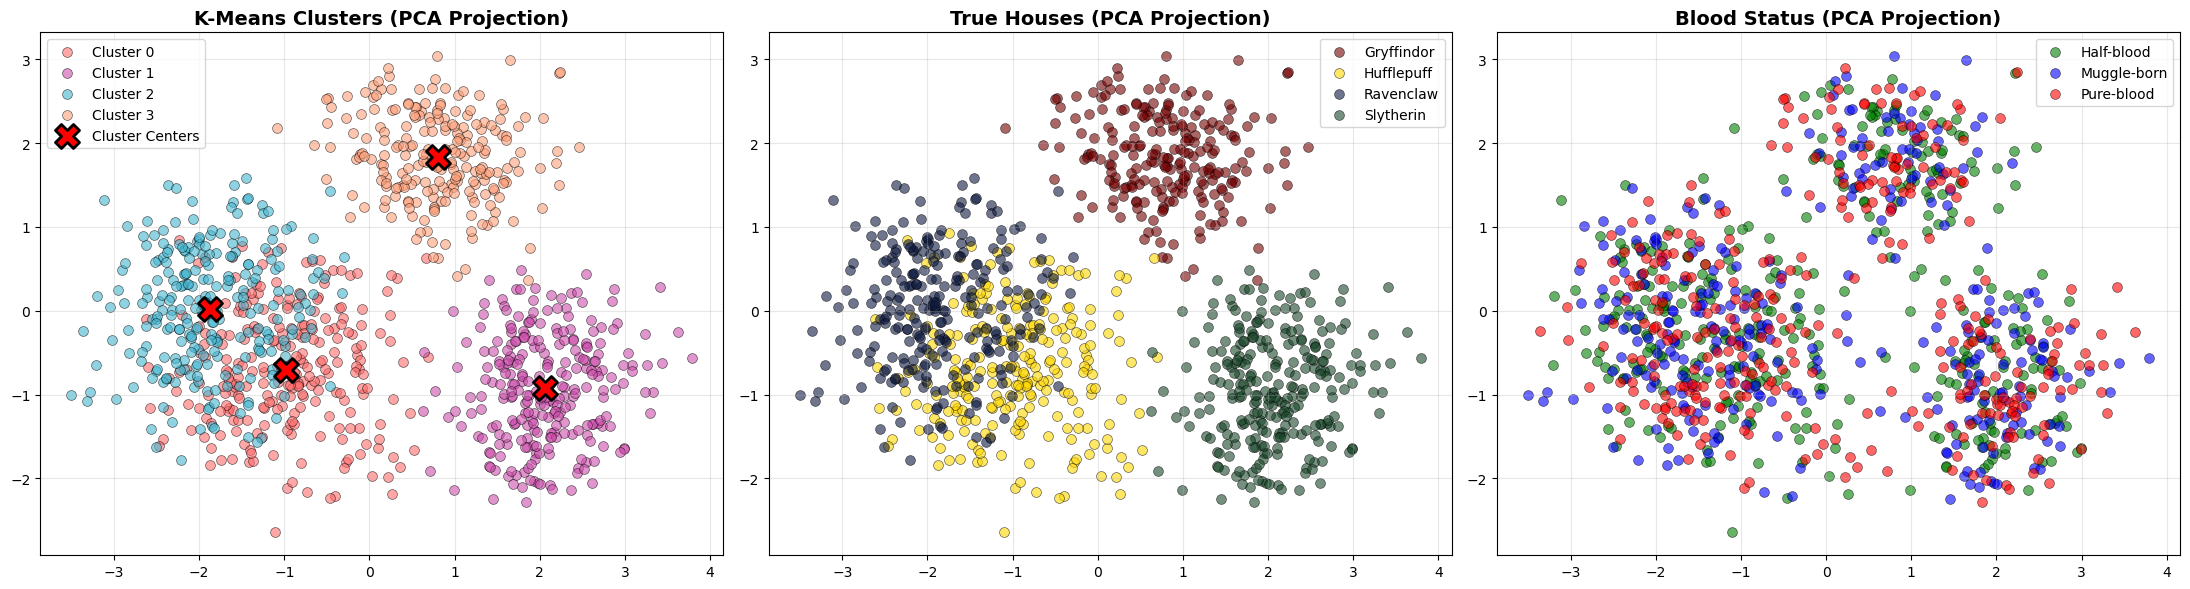

In [48]:
# Apply PCA to reduce the dimensions of clusters to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Define colors for clusters, houses, and blood status
cluster_colors = ['#FF6B6B', "#CD4EAD", '#45B7D1', '#FFA07A']
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}

# Plot 1: Colored by Cluster
ax1 = axes[0]
for cluster in range(4):
    mask = clusters == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[cluster], 
               label=f'Cluster {cluster}',
               alpha=0.6, 
               s=50,
               edgecolors='black',
               linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black',
           linewidth=2,
           label='Cluster Centers',
           zorder=5)


ax1.set_title('K-Means Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by True House
ax2 = axes[1]
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)


ax2.set_title('True Houses (PCA Projection)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by Blood Status
ax3 = axes[2]
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)


ax3.set_title('Blood Status (PCA Projection)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Clustering datapoints to correspond more to the lore from a subjective viewpoint

### Seeing which attributes correlate with probability of being Slytherin


SLYTHERIN PROBABILITY ANALYSIS
Model trained. Classes: ['Gryffindor' 'Hufflepuff' 'Ravenclaw' 'Slytherin']

Creating probability plots...


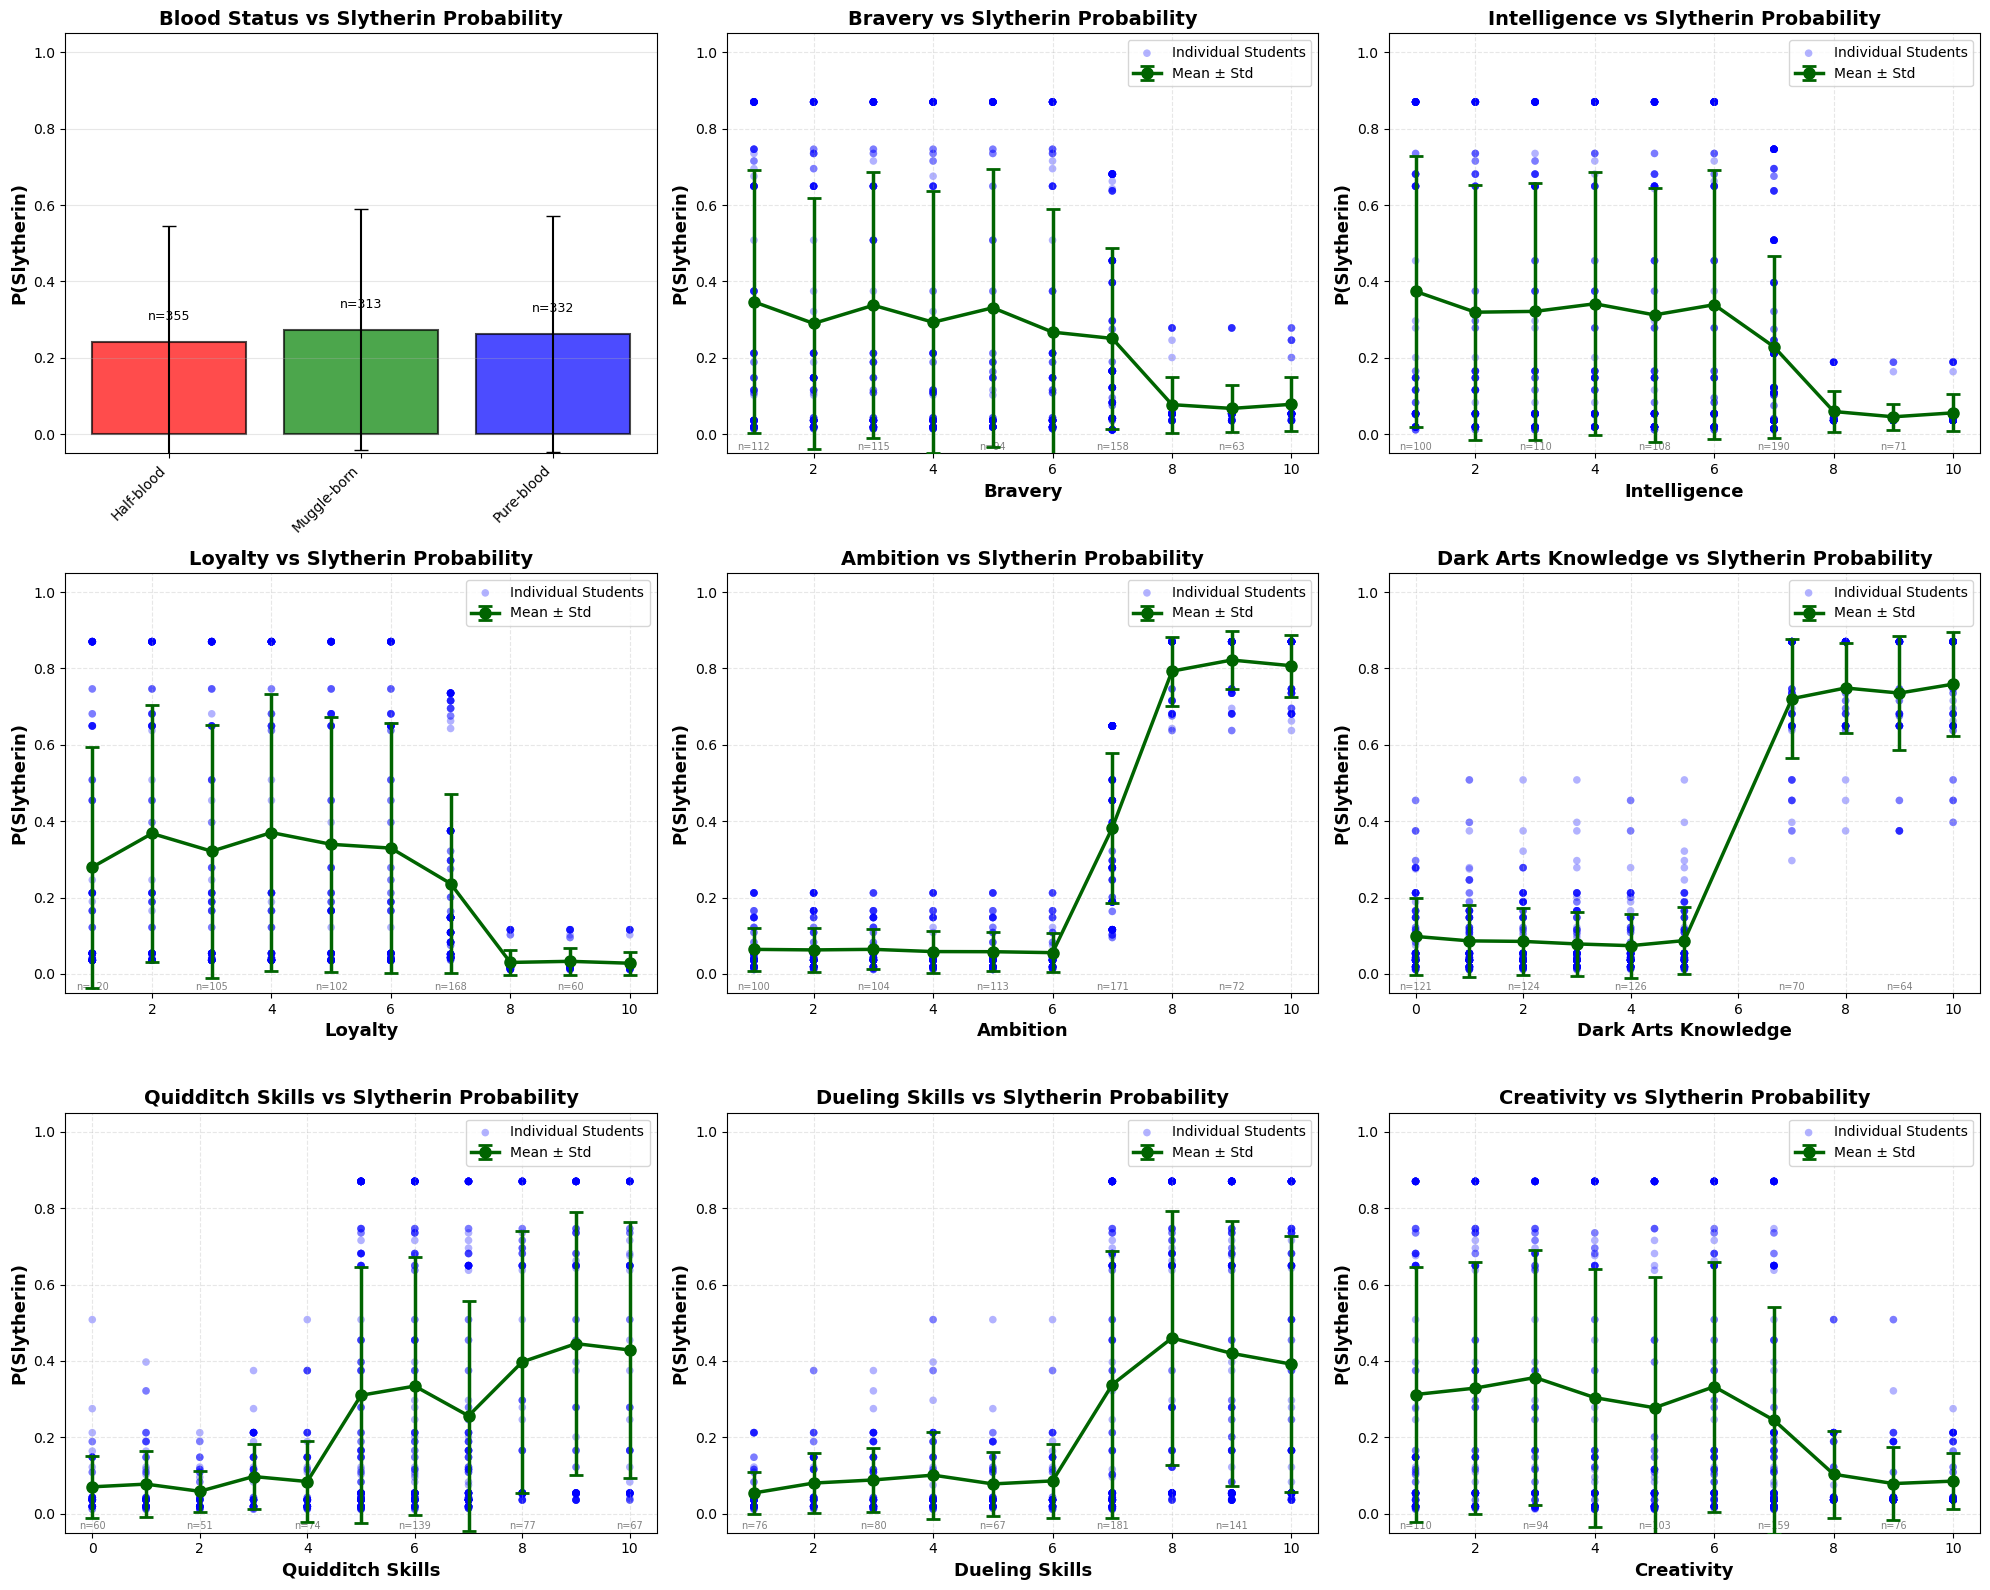

In [49]:
# USE RANDOM FOREST TO PREDICT SLYTHERIN PROBABILITIES
print("\n" + "="*60)
print("SLYTHERIN PROBABILITY ANALYSIS")
print("="*60)

# Get predicted probabilities for all houses
probs = rf_clf.predict_proba(X)
house_names = rf_clf.classes_

# Get Slytherin probabilities
slytherin_idx = np.where(house_names == 'Slytherin')[0][0]
slytherin_probs = probs[:, slytherin_idx]

# Add to dataframe
df['Slytherin_Probability'] = slytherin_probs

print(f"Model trained. Classes: {house_names}")

# CREATE PLOTS FOR ALL FEATURES
print("\nCreating probability plots...")

features_to_plot = ['Blood Status', 'Bravery', 'Intelligence', 'Loyalty', 
                    'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                    'Dueling Skills', 'Creativity']
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Handle Blood Status separately (categorical)
    if feature == 'Blood Status':
        blood_status_probs = df.groupby('Blood Status')['Slytherin_Probability'].agg(['mean', 'std', 'count'])
        
        blood_types = blood_status_probs.index
        means = blood_status_probs['mean'].values
        stds = blood_status_probs['std'].values
        counts = blood_status_probs['count'].values
        
        x_pos = np.arange(len(blood_types))
        bars = ax.bar(x_pos, means, yerr=stds, capsize=5, 
                     color=['red', 'green', 'blue'], 
                     alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(blood_types, rotation=45, ha='right')
        ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
        ax.set_title(f'{feature} vs Slytherin Probability', 
                    fontsize=14, fontweight='bold')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add count labels
        for i, (bar, count) in enumerate(zip(bars, counts)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'n={count}', ha='center', va='bottom', fontsize=9)
        
        continue
    
    # Get feature values and corresponding Slytherin probabilities
    feature_values = df[feature].values
    probs_for_feature = df['Slytherin_Probability'].values
    
    # Calculate mean probability for each feature value
    unique_values = np.sort(df[feature].unique())
    mean_probs = []
    std_probs = []
    counts = []
    
    for val in unique_values:
        mask = feature_values == val
        mean_probs.append(probs_for_feature[mask].mean())
        std_probs.append(probs_for_feature[mask].std())
        counts.append(mask.sum())
    
    mean_probs = np.array(mean_probs)
    std_probs = np.array(std_probs)
    
    # Scatter plot: all individual data points
    ax.scatter(feature_values, probs_for_feature, 
              alpha=0.3, s=30, c='blue', edgecolors='none',
              label='Individual Students')
    
    # Line plot: mean probability with error bars
    ax.errorbar(unique_values, mean_probs, yerr=std_probs,
               fmt='o-', color='darkgreen', linewidth=2.5, 
               markersize=8, capsize=5, capthick=2,
               label='Mean ± Std', zorder=5)
    
    
    # Formatting
    ax.set_xlabel(feature, fontsize=13, fontweight='bold')
    ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
    ax.set_title(f'{feature} vs Slytherin Probability', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([-0.05, 1.05])
    ax.legend(loc='best', fontsize=10)
    
    # Add sample size annotations at the bottom
    for i, (val, count) in enumerate(zip(unique_values, counts)):
        if i % 2 == 0:  # Show every other to avoid crowding
            ax.text(val, -0.02, f'n={count}', 
                   ha='center', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

df.drop('Slytherin_Probability', axis=1, inplace=True)


### feature engineering 'prejudice' on original dataset

In [50]:
# SLYTHERIN PREJUDICE FEATURE ENGINEERING
def calculate_prejudice_factor(row):
    """
    Calculate prejudice factor based on House and Blood Status only for the Slytherin house.
    
    """
    # define prejudice factors
    if row['House'] == 'Slytherin':
        if row['Blood Status'] == 'Pure-blood':
            return 1.0
        elif row['Blood Status'] == 'Half-blood':
            return 0.7
        elif row['Blood Status'] == 'Muggle-born':
            return 0.5
    return 1.0 # No prejudice for other houses

# Apply the prejudice factor and create new columns
prejudice_factor = df.apply(calculate_prejudice_factor, axis=1)
df['slytherin_prejudice_ambition'] = df['Ambition'] * prejudice_factor
df['slytherin_prejudice_dark_arts'] = df['Dark Arts Knowledge'] * prejudice_factor

df = df[[col for col in df.columns if col != 'House'] + ['House']] # reorder columns


## Clustering using the feature engineered columns


K-MEANS CLUSTERING (UNSUPERVISED)

Features used for clustering:
  - Bravery
  - Intelligence
  - Loyalty
  - slytherin_prejudice_ambition
  - slytherin_prejudice_dark_arts
  - Quidditch Skills
  - Dueling Skills
  - Creativity
  - Blood Status Encoded

Applying K-means with 4 clusters...

------------------------------------------------------------
Cluster-to-House Mapping (based on majority):
------------------------------------------------------------
  Cluster 0 → Gryffindor   (225/267 = 84.3%)
  Cluster 1 → Ravenclaw    (258/260 = 99.2%)
  Cluster 2 → Hufflepuff   (249/251 = 99.2%)
  Cluster 3 → Slytherin    (220/222 = 99.1%)

------------------------------------------------------------
Cluster Centers (Average Traits):
------------------------------------------------------------

Feature             Cluster 0  Cluster 1  Cluster 2  Cluster 3  
------------------------------------------------------------
Bravery                   8.25      4.13      3.83      3.56
Intelligence   

/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_8634/680062990.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster_prejudice'] = clusters


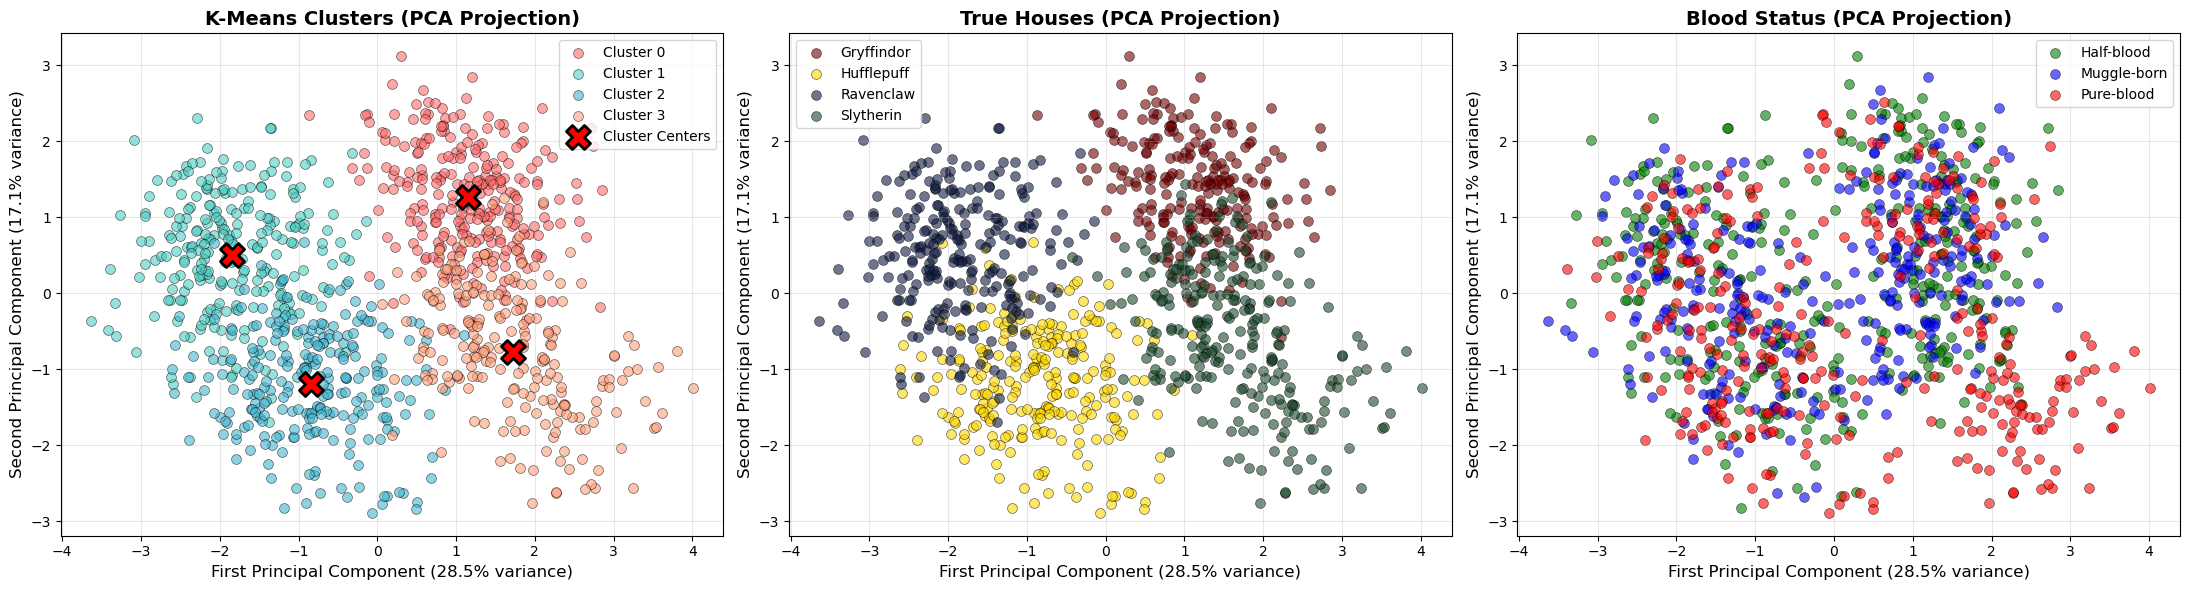

In [51]:
# K-MEANS CLUSTERING
print("\n" + "="*60)
print("K-MEANS CLUSTERING (UNSUPERVISED)")
print("="*60)

# Prepare features for clustering (only numerical attributes, no Blood Status)
cluster_features = ['Bravery', 'Intelligence', 'Loyalty', 'slytherin_prejudice_ambition', 
                    'slytherin_prejudice_dark_arts', 'Quidditch Skills', 'Dueling Skills', 'Creativity', 'Blood Status Encoded']

X_cluster = df[cluster_features].values

# Standardize features (important for K-means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("\nFeatures used for clustering:")
for feat in cluster_features:
    print(f"  - {feat}")

# Apply K-means with 4 clusters (for 4 houses)
print("\nApplying K-means with 4 clusters...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to dataframe
df['Cluster_prejudice'] = clusters


# Find which cluster corresponds to which house (based on majority)
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Cluster_prejudice'].unique()):
    house_counts = df[df['Cluster_prejudice'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Cluster_prejudice'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Show cluster centers (average traits per cluster)
print("\n" + "-"*60)
print("Cluster Centers (Average Traits):")
print("-"*60)
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\n{'Feature':20s}", end='')
for i in range(4):
    print(f"Cluster {i:1d}  ", end='')
print()
print("-" * 60)
for i, feat in enumerate(cluster_features):
    print(f"{feat:20s}", end='')
    for j in range(4):
        print(f"{cluster_centers_original[j,i]:10.2f}", end='')
    print()

# Apply PCA to reduce the dimensions of clusters to 2D for visualization
print("\n" + "="*60)
print("PCA VISUALIZATION OF CLUSTERS")
print("="*60)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Define colors for clusters, houses, and blood status
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}

# Plot 1: Colored by Cluster
ax1 = axes[0]
for cluster in range(4):
    mask = clusters == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[cluster], 
               label=f'Cluster {cluster}',
               alpha=0.6, 
               s=50,
               edgecolors='black',
               linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black',
           linewidth=2,
           label='Cluster Centers',
           zorder=5)

ax1.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax1.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.set_title('K-Means Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by True House
ax2 = axes[1]
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax2.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax2.set_title('True Houses (PCA Projection)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by Blood Status
ax3 = axes[2]
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax3.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax3.set_title('Blood Status (PCA Projection)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [52]:
# Check for half-bloods or muggle-borns with this method of clustering
cluster_non_pureblood = df[(df['Cluster_prejudice'] == 3) & (df['Blood Status'].isin(['Half-blood', 'Muggle-born']))]

print(f"Non-purebloods in Cluster 1: {len(cluster_non_pureblood)}")
print(f"  Half-bloods: {len(df[(df['Cluster_prejudice'] == 3) & (df['Blood Status'] == 'Half-blood')])}")
print(f"  Muggle-borns: {len(df[(df['Cluster_prejudice'] == 3) & (df['Blood Status'] == 'Muggle-born')])}")

# Show the breakdown
print("\nCluster 1 Blood Status breakdown:")
print(df[df['Cluster_prejudice'] == 3]['Blood Status'].value_counts())

Non-purebloods in Cluster 1: 132
  Half-bloods: 82
  Muggle-borns: 50

Cluster 1 Blood Status breakdown:
Blood Status
Pure-blood     90
Half-blood     82
Muggle-born    50
Name: count, dtype: int64


## Clustering using the feature engineered columns and adding weights to 'Blood Status Encoded'


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Applying dynamic weighted K-means with 4 clusters...

VISUALIZING DYNAMIC WEIGHTED CLUSTERS


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_8634/2852411356.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dynamic_Cluster'] = clusters_dynamic
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_8634/2852411356.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Blood_Status_Weight'] = blood_status_weights


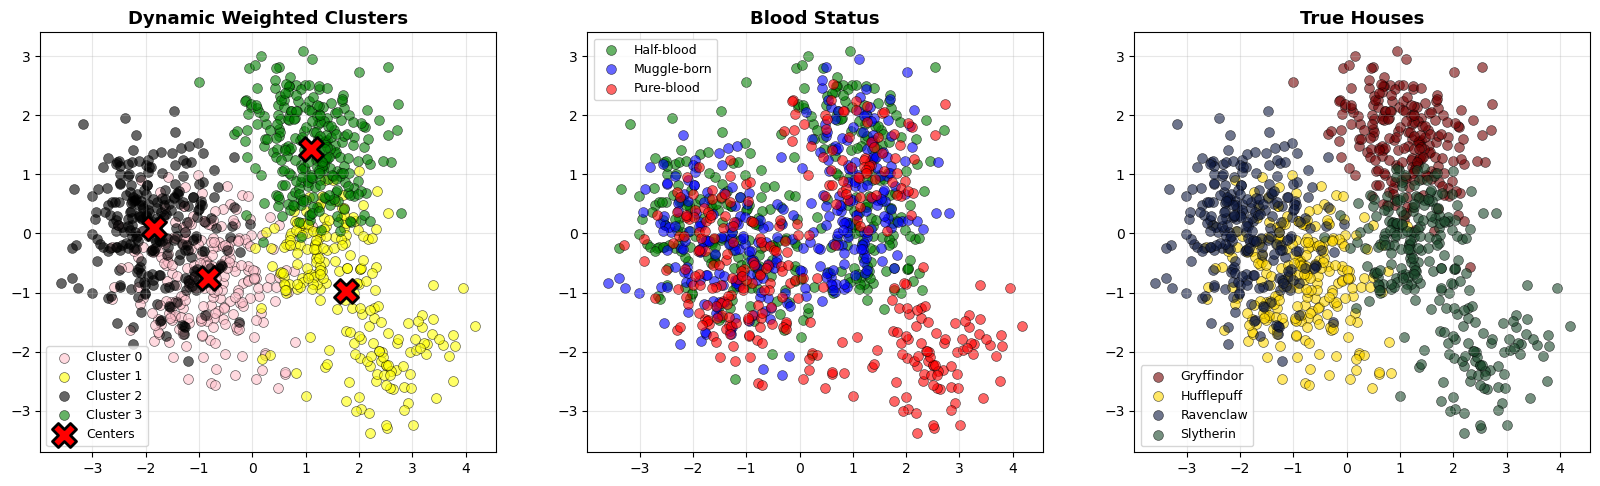

In [53]:
# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)


# Prepare features
cluster_features_dynamic = ['Blood Status Encoded','Bravery', 'Intelligence', 'Loyalty', 'slytherin_prejudice_ambition', 
                    'slytherin_prejudice_dark_arts', 'Quidditch Skills', 'Dueling Skills', 'Creativity']


X_dynamic = df[cluster_features_dynamic].values

# Extract Slytherin prejudice features
slytherin_prejudice_ambition = X_dynamic[:, 4]
slytherin_prejudice_dark_arts = X_dynamic[:, 5]


# Normalize these attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

slytherin_prejudice_ambition_norm = normalize(slytherin_prejudice_ambition)
slytherin_prejudice_dark_arts_norm = normalize(slytherin_prejudice_dark_arts)


# Create dynamic weight for Blood Status based on Ambition and Dark Arts
base_weight = 1.0  # normal weight before scaling
scaling_factor = 0.43  # Maximum additional weight


# Calculate per-instance blood status weight
# Increasing the value of 'blood status weight' if character has high weighted ambition and  weighted dark arts knowledge
blood_status_weights = base_weight + scaling_factor * (slytherin_prejudice_ambition_norm * slytherin_prejudice_dark_arts_norm)


# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)


# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights


# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['pink', 'yellow', 'black', 'green']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)


ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)


ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)


ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)




# Incorrect way of adding weights but produced good results


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Applying dynamic weighted K-means with 4 clusters...

VISUALIZING DYNAMIC WEIGHTED CLUSTERS


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_8634/545068840.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dynamic_Cluster'] = clusters_dynamic
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_8634/545068840.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Blood_Status_Weight'] = blood_status_weights


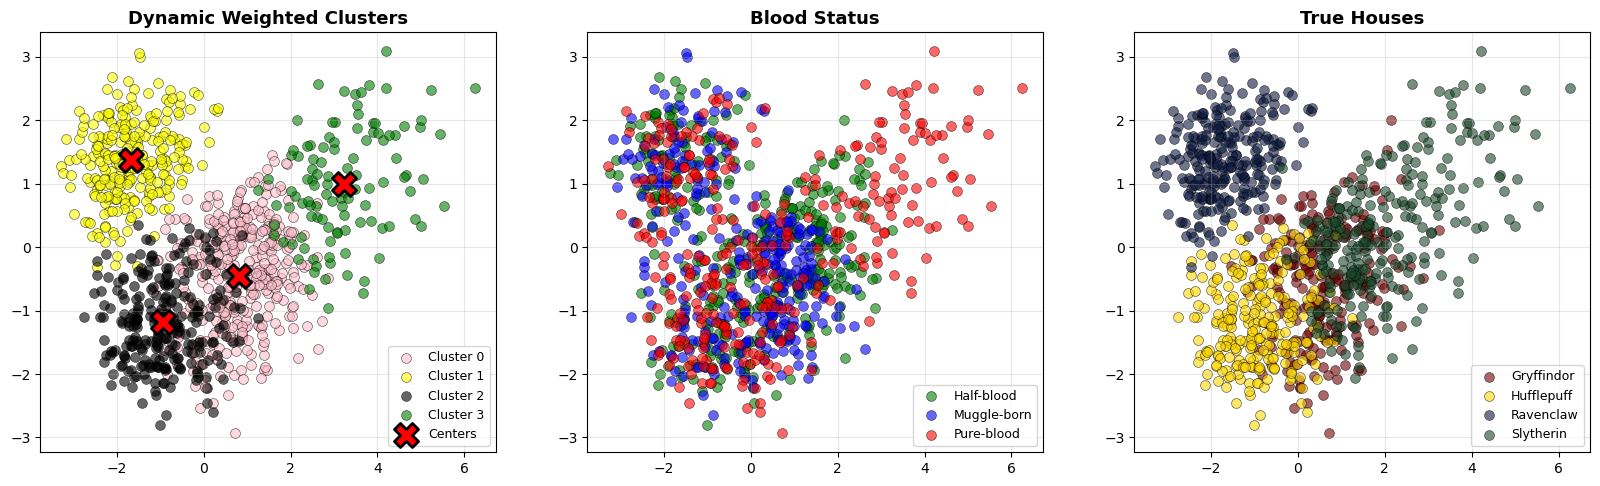

In [54]:
# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)


# Prepare features
cluster_features_dynamic = ['Bravery', 'Intelligence', 'Loyalty', 'slytherin_prejudice_ambition', 
                    'slytherin_prejudice_dark_arts', 'Quidditch Skills', 'Dueling Skills', 'Creativity']


X_dynamic = df[cluster_features_dynamic].values

# Extract Slytherin prejudice features
slytherin_prejudice_ambition = X_dynamic[:, 3]
slytherin_prejudice_dark_arts = X_dynamic[:, 4]
blood_status_pre = X_dynamic[:, 0]


# Normalize these attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

slytherin_prejudice_ambition_norm = normalize(slytherin_prejudice_ambition)
slytherin_prejudice_dark_arts_norm = normalize(slytherin_prejudice_dark_arts)


# Create dynamic weight for Blood Status based on Ambition and Dark Arts
base_weight = 1.0  # normal weight before scaling
scaling_factor = 50  # Maximum additional weight
power = 2.5  # Exponent to amplify high values (makes the effect non-linear)


# Calculate per-instance blood status weight
# Increasing the value of 'blood status weight' if character has high weighted ambition and  weighted dark arts knowledge
blood_status_weights = base_weight + scaling_factor * (slytherin_prejudice_ambition_norm * slytherin_prejudice_dark_arts_norm)


# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)


# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights


# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['pink', 'yellow', 'black', 'green']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)


ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)


ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)



In [55]:
# Check for half-bloods or muggle-borns with this method of clustering
cluster_non_pureblood = df[(df['Dynamic_Cluster'] == 3) & (df['Blood Status'].isin(['Half-blood', 'Muggle-born']))]

print(f"Non-purebloods in Cluster 1: {len(cluster_non_pureblood)}")
print(f"  Half-bloods: {len(df[(df['Dynamic_Cluster'] == 3) & (df['Blood Status'] == 'Half-blood')])}")
print(f"  Muggle-borns: {len(df[(df['Dynamic_Cluster'] == 3) & (df['Blood Status'] == 'Muggle-born')])}")

# Show the breakdown
print("\nCluster 1 Blood Status breakdown:")
print(df[df['Dynamic_Cluster'] == 3]['Blood Status'].value_counts())

Non-purebloods in Cluster 1: 23
  Half-bloods: 21
  Muggle-borns: 2

Cluster 1 Blood Status breakdown:
Blood Status
Pure-blood     86
Half-blood     21
Muggle-born     2
Name: count, dtype: int64
